In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scanpy as sc

In [2]:
rng = np.random.default_rng(423)

In [3]:
# load pcRNA
adata_pcRNA = ad.read_h5ad("../HEK293T/TotalX_HEK293T_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("../HEK293T/TotalX_HEK293T_miRNA.h5ad")

# load capture
beta = np.loadtxt("../HEK293T/TotalX_HEK293T_capture.txt")

In [5]:
# copy and fix gene names
adata_cc = adata_pcRNA.copy()
adata_cc.var_names = adata_cc.var['GeneName'].values.tolist()
adata_cc

AnnData object with n_obs × n_vars = 11945 × 10307
    var: 'gene_ids', 'feature_types', 'genome', 'GeneName', 'gene_id', 'biotype'
    layers: None (.X)

In [11]:
# load cell cycle genes
cell_cycle_genes = [x.strip() for x in open("regev_lab_cell_cycle_genes.txt")]

# Split into 2 lists
s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]

# subset to observed
s_genes_data = [x for x in s_genes if x in adata_cc.var_names]
g2m_genes_data = [x for x in g2m_genes if x in adata_cc.var_names]
cell_cycle_genes_data = [x for x in cell_cycle_genes if x in adata_cc.var_names]

print(f"S phase genes present: {len(s_genes_data)} / {len(s_genes)}")
print(f"G2M phase genes present: {len(g2m_genes_data)} / {len(g2m_genes)}")
print(f"Total: {len(cell_cycle_genes_data)} / {len(cell_cycle_genes)}")

S phase genes present: 42 / 43
G2M phase genes present: 52 / 54
Total: 94 / 97


In [12]:
# NOTE: filtering already done, so below lines have no effect
# sc.pp.filter_cells(adata_cc, min_genes=200)
# sc.pp.filter_genes(adata_cc, min_cells=3)

# normalize and log transform
sc.pp.normalize_total(adata_cc, target_sum=1e4)
sc.pp.log1p(adata_cc)

In [ ]:
# run scoring
sc.tl.score_genes_cell_cycle(adata_cc, s_genes=s_genes_data, g2m_genes=g2m_genes_data)

In [27]:
# results
adata_cc.obs['phase'].value_counts()

phase
S      6285
G2M    5217
G1      443
Name: count, dtype: int64

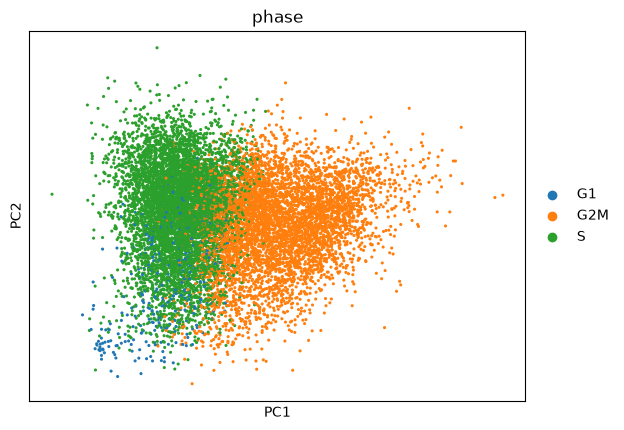

In [22]:
# display PCA
adata_cc_genes = adata_cc[:, cell_cycle_genes_data].copy()
sc.tl.pca(adata_cc_genes)
sc.pl.pca(adata_cc_genes, color="phase", s=20)

In [28]:
# store cell cycle info on adata
adata_pcRNA.obs['S_score'] = adata_cc.obs['S_score']
adata_pcRNA.obs['G2M_score'] = adata_cc.obs['G2M_score']
adata_pcRNA.obs['phase'] = adata_cc.obs['phase']

adata_miRNA.obs['S_score'] = adata_cc.obs['S_score']
adata_miRNA.obs['G2M_score'] = adata_cc.obs['G2M_score']
adata_miRNA.obs['phase'] = adata_cc.obs['phase']

In [29]:
# split capture by phase
beta_G1 = beta[adata_cc.obs['phase'] == "G1"]
beta_S = beta[adata_cc.obs['phase'] == "S"]
beta_G2M = beta[adata_cc.obs['phase'] == "G2M"]

In [33]:
# save counts with cell cycle info
adata_pcRNA.write_h5ad("TotalX_HEK293T_CC_pcRNA.h5ad")
adata_miRNA.write_h5ad("TotalX_HEK293T_CC_miRNA.h5ad")

# save capture
np.savetxt("TotalX_HEK293T_G1_capture.txt", beta_G1)
np.savetxt("TotalX_HEK293T_S_capture.txt", beta_S)
np.savetxt("TotalX_HEK293T_G2M_capture.txt", beta_G2M)